# Developer Skills Ecosystem Analysis: A Multi-Platform Study

**Author:** Krishna Kishore Madathingal  
**Email:** kmadath@iu.edu  
**Date:** December 2025

## Research Questions

**RQ1 (Networks):** How do technology skills cluster into communities across different developer roles?

**RQ2 (Text Analysis):** How do developers describe their expertise differently across platforms?

**RQ3 (Machine Learning):** Can we predict a developer's specialization from their technology stack?

This notebook implements the complete analysis pipeline.

## 1. Setup and Imports

In [1]:
# Core libraries
import pandas as pd
import numpy as np
import json
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline

# Network analysis
import networkx as nx
from networkx.algorithms import community

# Text analysis
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import re

# Machine learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score,
    precision_recall_fscore_support
)

# Set random seed
np.random.seed(42)

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


## 2. Data Loading and Preprocessing

### 2.1 Load Stack Overflow Survey Data

In [2]:
# Load Stack Overflow survey data
# This should be the cleaned version from data_collection_script.py

try:
    so_df = pd.read_csv('stackoverflow_survey_cleaned.csv')
    print(f"✓ Loaded Stack Overflow data: {len(so_df)} responses")
    print(f"✓ Columns: {so_df.shape[1]}")
    print(f"\nFirst few rows:")
    display(so_df.head())
except FileNotFoundError:
    print("ERROR: stackoverflow_survey_cleaned.csv not found!")
    print("Please run data_collection_script.py first")

✓ Loaded Stack Overflow data: 57395 responses
✓ Columns: 114

First few rows:


,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
1,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
2,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
3,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN
4,6,I code primarily as a hobby,Under 18 years old,"Student, full-time",NaN,Apples,NaN,Primary/elementary school,"School (i.e., University, College, etc);Online...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN


### 2.2 Load GitHub Profile Data

In [3]:
# Load GitHub profiles
try:
    github_df = pd.read_csv('github_profiles.csv')
    print(f"✓ Loaded GitHub data: {len(github_df)} profiles")
    print(f"✓ Columns: {github_df.shape[1]}")
    print(f"\nFirst few rows:")
    display(github_df.head())
except FileNotFoundError:
    print("ERROR: github_profiles.csv not found!")
    print("Please run data_collection_script.py first")

✓ Loaded GitHub data: 303 profiles
✓ Columns: 13

First few rows:


,username,name,bio,company,location,public_repos,followers,following,created_at,languages,top_language,topics,num_languages
0,jnolis,Jacqueline Nolis,Data Scientist,Fanatics,"Seattle, WA",43,350,9,2013-01-19T21:29:57Z,"R,Dockerfile,HTML,CSS,SCSS,JavaScript",R,NaN,6
1,kmayerb,Koshlan Mayer-Blackwell,Data Scientist,Fred Hutch,"Seattle, WA",97,25,16,2019-01-13T02:55:06Z,"Python,Dockerfile,R,Shell,Rebol",Python,NaN,5
2,camoverride,Cameron Smith,Seattle-based artist. ex data scientist 📈,NaN,Seattle,43,241,4,2016-06-10T01:05:47Z,"Python,HTML,SCSS",Python,"video,audio-processing,ghosts,math,segmentatio...",3
3,dgergel,Diana Gergel,Climate Scientist | Data Scientist,RWE AI Lab,"Seattle, WA",25,29,32,2013-07-16T00:21:31Z,"Fortran,Makefile,Shell,Python,Jupyter Notebook...",Jupyter Notebook,NaN,6
4,chhayac,Chhaya Choudhary,Data Scientist @ Infoblox | MS in Data Science...,Infoblox,Seattle,16,308,8,2016-04-09T20:38:04Z,"Jupyter Notebook,C,Java,Python,C++,CMake",Jupyter Notebook,"apartmentguide,notebook,webscraper,deep-learni...",6


### 2.3 Data Preprocessing and Role Standardization

In [4]:
# Role standardization mapping for Stack Overflow
# Stack Overflow uses semicolon-separated multi-select

ROLE_MAPPING = {
    'Data scientist or machine learning specialist': 'Data Scientist',
    'Data or business analyst': 'Data Analyst',
    'Developer, back-end': 'Backend Developer',
    'Developer, front-end': 'Frontend Developer',
    'Developer, full-stack': 'Full Stack Developer',
    'Developer, mobile': 'Mobile Developer',
    'DevOps specialist': 'DevOps Engineer',
    'Engineer, data': 'Data Engineer',
    'Developer, desktop or enterprise applications': 'Software Engineer',
    'System administrator': 'System Administrator',
    'Developer, QA or test': 'QA Engineer',
    'Product manager': 'Product Manager',
    'Designer': 'Designer'
}

def standardize_role(role_string):
    """
    Standardize developer role from Stack Overflow format.
    Takes first matching role if multiple are listed.
    """
    if pd.isna(role_string):
        return 'Other'
    
    # Split by semicolon (Stack Overflow format)
    roles = [r.strip() for r in str(role_string).split(';')]
    
    # Try to find a match in our mapping
    for role in roles:
        if role in ROLE_MAPPING:
            return ROLE_MAPPING[role]
        # Partial matches
        role_lower = role.lower()
        if 'data scientist' in role_lower or 'machine learning' in role_lower:
            return 'Data Scientist'
        elif 'data engineer' in role_lower:
            return 'Data Engineer'
        elif 'devops' in role_lower:
            return 'DevOps Engineer'
        elif 'front-end' in role_lower or 'frontend' in role_lower:
            return 'Frontend Developer'
        elif 'back-end' in role_lower or 'backend' in role_lower:
            return 'Backend Developer'
        elif 'full stack' in role_lower or 'full-stack' in role_lower:
            return 'Full Stack Developer'
    
    return 'Other'

# Apply role standardization
role_column = 'DevType'

if role_column in so_df.columns:
    so_df['role_std'] = so_df[role_column].apply(standardize_role)
    print("✓ Standardized Stack Overflow roles")
    print(f"\nRole distribution:")
    print(so_df['role_std'].value_counts())
else:
    print(f"WARNING: Column '{role_column}' not found. Available columns:")
    print(so_df.columns.tolist())

✓ Standardized Stack Overflow roles

Role distribution:
role_std
Full Stack Developer    17737
Other                   17430
Backend Developer        9620
Frontend Developer       3220
Software Engineer        2419
Mobile Developer         1946
Data Engineer            1086
DevOps Engineer           993
Data Scientist            990
System Administrator      518
QA Engineer               497
Data Analyst              491
Product Manager           279
Designer                  169
Name: count, dtype: int64


In [5]:
# Filter to top roles for cleaner analysis
TOP_ROLES = ['Data Scientist', 'Backend Developer', 'Frontend Developer', 
             'DevOps Engineer', 'QA Engineer']

so_df_filtered = so_df[so_df['role_std'].isin(TOP_ROLES)].copy()

print(f"✓ Filtered to top {len(TOP_ROLES)} roles")
print(f"✓ Dataset size: {len(so_df_filtered)} respondents")
print(f"\nFiltered distribution:")
print(so_df_filtered['role_std'].value_counts())

✓ Filtered to top 5 roles
✓ Dataset size: 15320 respondents

Filtered distribution:
role_std
Backend Developer     9620
Frontend Developer    3220
DevOps Engineer        993
Data Scientist         990
QA Engineer            497
Name: count, dtype: int64


### 2.4 Process Technology/Language Data

In [6]:
# Process languages/technologies from Stack Overflow
# Stack Overflow uses semicolon-separated values
print("Processing ALL technology columns (not just languages)...")

# Stack Overflow 2024 has multiple technology columns
tech_columns = [
    'LanguageHaveWorkedWith',
    'DatabaseHaveWorkedWith', 
    'PlatformHaveWorkedWith',
    'WebframeHaveWorkedWith',
    'MiscTechHaveWorkedWith'
]

def combine_all_tech_columns(row):
    """
    Combine all technology columns into one comprehensive list.
    This gives the model MORE information to work with.
    """
    all_techs = []
    
    for col in tech_columns:
        if col in so_df_filtered.columns and pd.notna(row[col]):
            # Split by semicolon (Stack Overflow format)
            techs = [t.strip() for t in str(row[col]).split(';') if t.strip()]
            all_techs.extend(techs)
    
    # Remove duplicates while preserving order
    seen = set()
    unique_techs = []
    for tech in all_techs:
        if tech not in seen:
            seen.add(tech)
            unique_techs.append(tech)
    
    return unique_techs

# Apply to dataset
print("\nCombining technology columns...")
so_df_filtered['technologies'] = so_df_filtered.apply(combine_all_tech_columns, axis=1)
so_df_filtered['tech_count'] = so_df_filtered['technologies'].apply(len)

# Show stats
print(f"✓ Technologies processed")
print(f"✓ Average techs per person: {so_df_filtered['tech_count'].mean():.1f}")
print(f"✓ Max techs: {so_df_filtered['tech_count'].max()}")
print(f"✓ Min techs: {so_df_filtered['tech_count'].min()}")

# Get all unique technologies
all_techs = []
for tech_list in so_df_filtered['technologies']:
    all_techs.extend(tech_list)

tech_counts = Counter(all_techs)
print(f"✓ Total unique technologies: {len(tech_counts)}")


Processing ALL technology columns (not just languages)...

Combining technology columns...
✓ Technologies processed
✓ Average techs per person: 13.2
✓ Max techs: 170
✓ Min techs: 1
✓ Total unique technologies: 185


## 3. Exploratory Data Analysis

In [7]:
# Dataset statistics
print("DATASET STATISTICS")
print("="*80)
print(f"\nStack Overflow Survey:")
print(f"  Total responses: {len(so_df_filtered)}")
print(f"  Unique roles: {so_df_filtered['role_std'].nunique()}")
print(f"  Avg technologies per person: {so_df_filtered['tech_count'].mean():.1f}")

print(f"\nGitHub Profiles:")
print(f"  Total profiles: {len(github_df)}")
print(f"  Profiles with bio: {github_df['bio'].notna().sum()}")
print(f"  Avg languages per profile: {github_df['num_languages'].mean():.1f}")
print(f"  Total unique languages: {len(set(','.join(github_df['languages'].dropna()).split(',')))}")

DATASET STATISTICS

Stack Overflow Survey:
  Total responses: 15320
  Unique roles: 5
  Avg technologies per person: 13.2

GitHub Profiles:
  Total profiles: 303
  Profiles with bio: 289
  Avg languages per profile: 10.1
  Total unique languages: 195


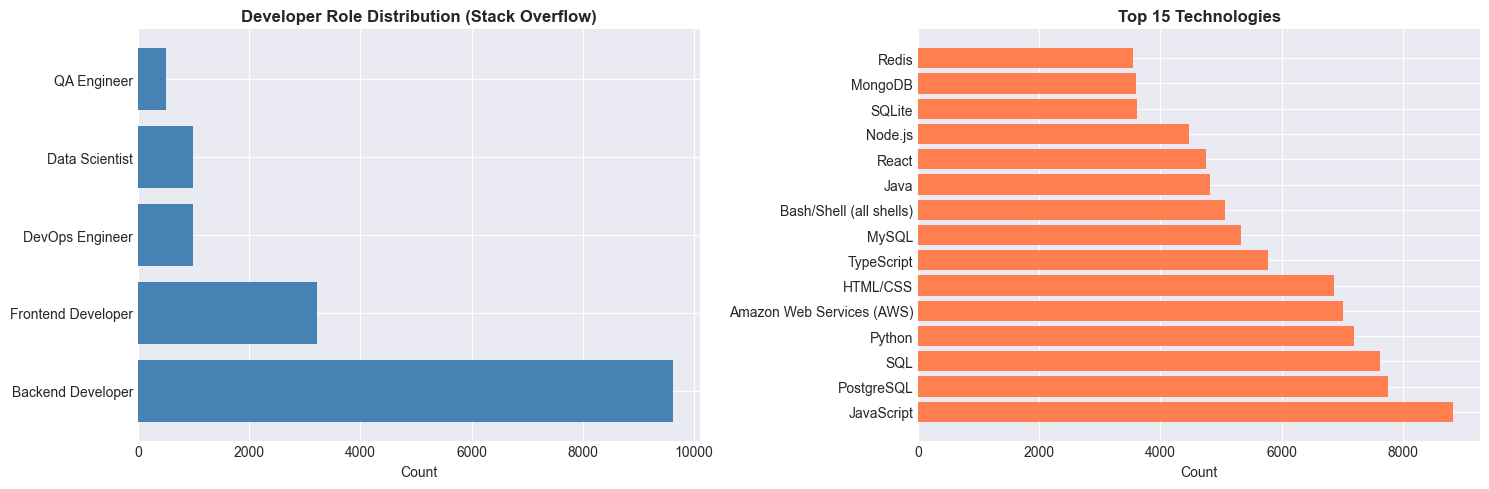

Figure saved as 'data_overview.png'


In [8]:
# Visualize role distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Stack Overflow roles
role_counts = so_df_filtered['role_std'].value_counts()
axes[0].barh(range(len(role_counts)), role_counts.values, color='steelblue')
axes[0].set_yticks(range(len(role_counts)))
axes[0].set_yticklabels(role_counts.index)
axes[0].set_xlabel('Count')
axes[0].set_title('Developer Role Distribution (Stack Overflow)', fontweight='bold')

# Top technologies
top_techs = tech_counts.most_common(15)
techs, counts = zip(*top_techs)
axes[1].barh(range(len(techs)), counts, color='coral')
axes[1].set_yticks(range(len(techs)))
axes[1].set_yticklabels(techs)
axes[1].set_xlabel('Count')
axes[1].set_title('Top 15 Technologies', fontweight='bold')

plt.tight_layout()
plt.savefig('data_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print("Figure saved as 'data_overview.png'")

## 4. RQ1: Technology Network Analysis (Networks - Weeks 6-7)

Build and analyze a co-occurrence network of technologies to identify skill communities.

In [9]:
def build_technology_network(df, tech_column='technologies', min_cooccurrence=10):
    """
    Build a weighted network of technology co-occurrences.
    
    Args:
        df: DataFrame with technology lists
        tech_column: Column name containing lists of technologies
        min_cooccurrence: Minimum co-occurrence to create an edge
    
    Returns:
        NetworkX Graph
    """
    G = nx.Graph()
    
    # Count co-occurrences
    cooccurrence = defaultdict(int)
    
    for tech_list in df[tech_column]:
        if not tech_list:
            continue
        
        # For each pair of technologies in a person's stack
        for i, tech1 in enumerate(tech_list):
            for tech2 in tech_list[i+1:]:
                # Create sorted tuple to avoid duplicates
                pair = tuple(sorted([tech1, tech2]))
                cooccurrence[pair] += 1
    
    # Add edges with weights
    for (tech1, tech2), count in cooccurrence.items():
        if count >= min_cooccurrence:
            G.add_edge(tech1, tech2, weight=count)
    
    print(f"Network created: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
    return G

# Build the technology network
tech_network = build_technology_network(so_df_filtered, min_cooccurrence=10)

# Network statistics
print(f"\nNetwork Statistics:")
print(f"  Nodes (technologies): {tech_network.number_of_nodes()}")
print(f"  Edges: {tech_network.number_of_edges()}")
print(f"  Density: {nx.density(tech_network):.4f}")
print(f"  Average degree: {sum(dict(tech_network.degree()).values()) / tech_network.number_of_nodes():.2f}")

# Check if network is connected
if nx.is_connected(tech_network):
    print(f"  Average path length: {nx.average_shortest_path_length(tech_network):.2f}")
    print(f"  Diameter: {nx.diameter(tech_network)}")
else:
    print(f"  Network has {nx.number_connected_components(tech_network)} components")
    largest_cc = max(nx.connected_components(tech_network), key=len)
    print(f"  Largest component: {len(largest_cc)} nodes")

Network created: 185 nodes, 11765 edges

Network Statistics:
  Nodes (technologies): 185
  Edges: 11765
  Density: 0.6912
  Average degree: 127.19
  Average path length: 1.31
  Diameter: 2


In [10]:
# Calculate centrality measures
print("Calculating centrality measures...")

degree_centrality = nx.degree_centrality(tech_network)
betweenness_centrality = nx.betweenness_centrality(tech_network)
eigenvector_centrality = nx.eigenvector_centrality(tech_network, max_iter=1000)

# Create centrality DataFrame
centrality_df = pd.DataFrame({
    'Technology': list(degree_centrality.keys()),
    'Degree': list(degree_centrality.values()),
    'Betweenness': list(betweenness_centrality.values()),
    'Eigenvector': list(eigenvector_centrality.values())
})

centrality_df = centrality_df.sort_values('Degree', ascending=False)

print("\nTop 15 Technologies by Centrality:")
print("="*80)
print(centrality_df.head(15).to_string(index=False))

# Save results
centrality_df.to_csv('technology_centrality.csv', index=False)
print("\n✓ Saved to 'technology_centrality.csv'")

Calculating centrality measures...

Top 15 Technologies by Centrality:
               Technology   Degree  Betweenness  Eigenvector
  Bash/Shell (all shells) 1.000000     0.007907     0.092298
                      SQL 1.000000     0.007907     0.092298
               PostgreSQL 1.000000     0.007907     0.092298
                   Python 1.000000     0.007907     0.092298
               JavaScript 1.000000     0.007907     0.092298
Amazon Web Services (AWS) 0.994565     0.007108     0.092238
                 HTML/CSS 0.994565     0.007227     0.092228
               TypeScript 0.994565     0.006748     0.092256
                     Java 0.994565     0.007108     0.092238
                    MySQL 0.994565     0.007108     0.092238
                    Redis 0.989130     0.005959     0.092196
                   SQLite 0.989130     0.006075     0.092186
                  Node.js 0.989130     0.005959     0.092196
                    React 0.983696     0.005295     0.092126
             G

In [11]:
# Community detection using Louvain algorithm
print("Detecting communities...")

communities = community.louvain_communities(tech_network, seed=42)

print(f"\nFound {len(communities)} communities")
print("\nTop Communities (3+ members):")
print("="*80)

for i, comm in enumerate(sorted(communities, key=len, reverse=True), 1):
    if len(comm) >= 3:
        print(f"\nCommunity {i} ({len(comm)} technologies):")
        print(', '.join(sorted(list(comm))))

# Create community membership dictionary
tech_community = {}
for i, comm in enumerate(communities):
    for tech in comm:
        tech_community[tech] = i

print(f"\n✓ Community detection complete")

Detecting communities...

Found 4 communities

Top Communities (3+ members):

Community 1 (61 technologies):
Alibaba Cloud, Angular, AngularJS, Astro, Capacitor, Cloud Firestore, Cloudflare, CodeIgniter, Cordova, Dart, Deno, Digital Ocean, Drupal, Electron, Express, Fastify, Firebase, Firebase Realtime Database, Flutter, Fly.io, GDScript, Gatsby, HTML/CSS, Heroku, Hetzner, Ionic, JavaScript, Laravel, Linode, now Akamai, Managed Hosting, MariaDB, MongoDB, MySQL, NestJS, Netlify, Next.js, Node.js, Nuxt.js, OVH, PHP, React, React Native, Remix, Render, Scaleway, Solid.js, Solidity, Strapi, Supabase, Svelte, Swift, SwiftUI, Symfony, Tauri, TypeScript, Vercel, Vue.js, Vultr, WordPress, Yii 2, jQuery

Community 2 (50 technologies):
Apache Spark, Assembly, C, C++, CUDA, Databricks, Databricks SQL, Django, DuckDB, FastAPI, Flask, Fortran, GTK, Hadoop, Haskell, Htmx, Hugging Face Transformers, IBM Cloud Or Watson, JAX, Julia, Keras, Lisp, Lua, MATLAB, MicroPython, Neo4J, Nim, NumPy, OCaml, Obje


Creating focused subgraph...


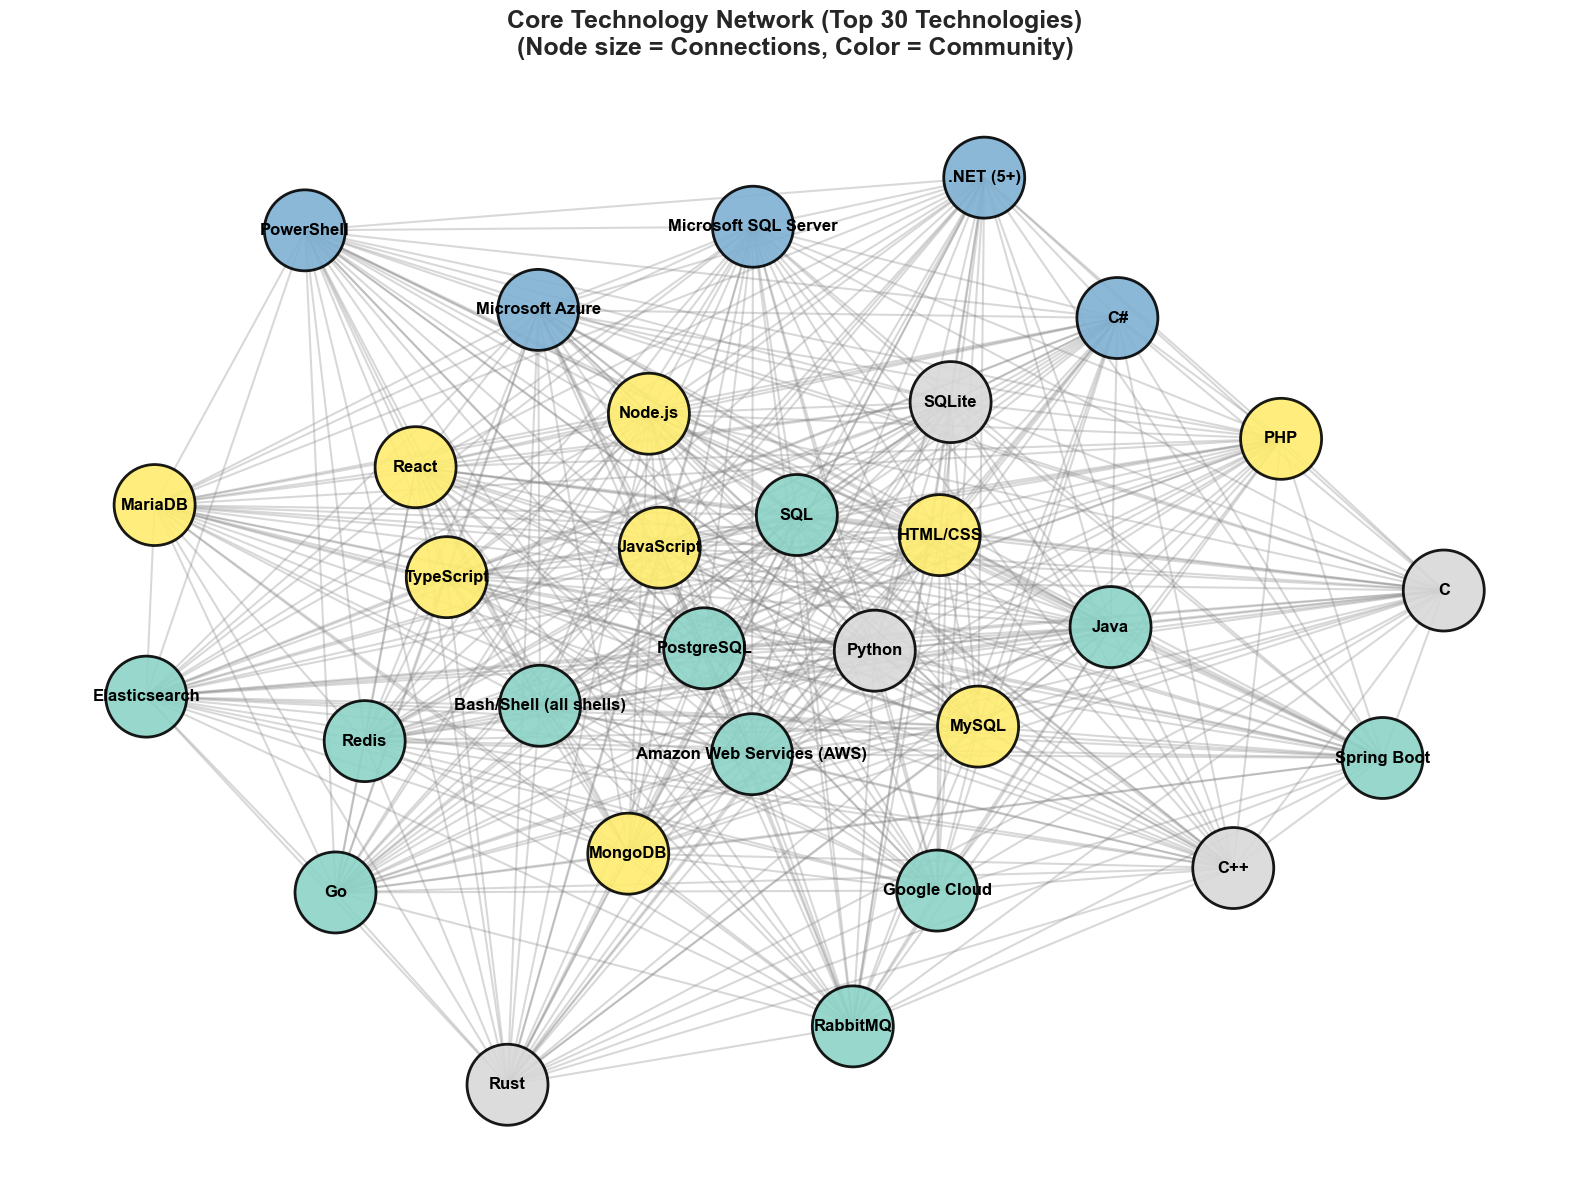

✓ Saved as 'technology_network_focused.png'
✓ Focused on most important 30 technologies

 technology_network_focused.png - Core 30 technologies


In [12]:
"""
Simpler, Better Network Visualization
This will actually work and look much better!
"""

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

# ============================================================================
# Create a focused subgraph of just the most important technologies
# ============================================================================

print("\nCreating focused subgraph...")

# Get top 30 most central nodes
top_30_nodes = centrality_df.head(30)['Technology'].tolist()

# Create subgraph
subgraph = tech_network.subgraph(top_30_nodes).copy()

fig, ax = plt.subplots(figsize=(16, 12), facecolor='white')

# Layout
pos_sub = nx.spring_layout(subgraph, k=2, iterations=50, seed=42)

# Colors
node_colors_sub = []
for node in subgraph.nodes():
    comm_id = 0
    for i, comm in enumerate(communities):
        if node in comm:
            comm_id = i
            break
    node_colors_sub.append(comm_id)

# Draw
nx.draw_networkx_edges(subgraph, pos_sub,
                       alpha=0.3,
                       width=1.5,
                       edge_color='gray',
                       ax=ax)

degree_dict_sub = dict(subgraph.degree())
node_sizes_sub = [500 + degree_dict_sub[node] * 100 for node in subgraph.nodes()]

nx.draw_networkx_nodes(subgraph, pos_sub,
                       node_color=node_colors_sub,
                       node_size=node_sizes_sub,
                       cmap=plt.cm.Set3,
                       alpha=0.9,
                       edgecolors='black',
                       linewidths=2,
                       ax=ax)

# Label ALL nodes (only 30 nodes now)
nx.draw_networkx_labels(subgraph, pos_sub,
                       font_size=12,
                       font_weight='bold',
                       font_color='black',
                       ax=ax)

ax.set_title('Core Technology Network (Top 30 Technologies)\n' +
             '(Node size = Connections, Color = Community)',
             fontsize=18, fontweight='bold', pad=20)

ax.axis('off')
plt.tight_layout()
plt.savefig('technology_network_focused.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("✓ Saved as 'technology_network_focused.png'")
print("✓ Focused on most important 30 technologies")
print("\n" + "="*80)
print(" technology_network_focused.png - Core 30 technologies")
print("="*80)

Creating hierarchical network with smart label positioning...
(No external dependencies required)
Computing hierarchical layout...
Drawing edges...
Drawing nodes...
Adding labels with smart positioning...
Adding community labels...


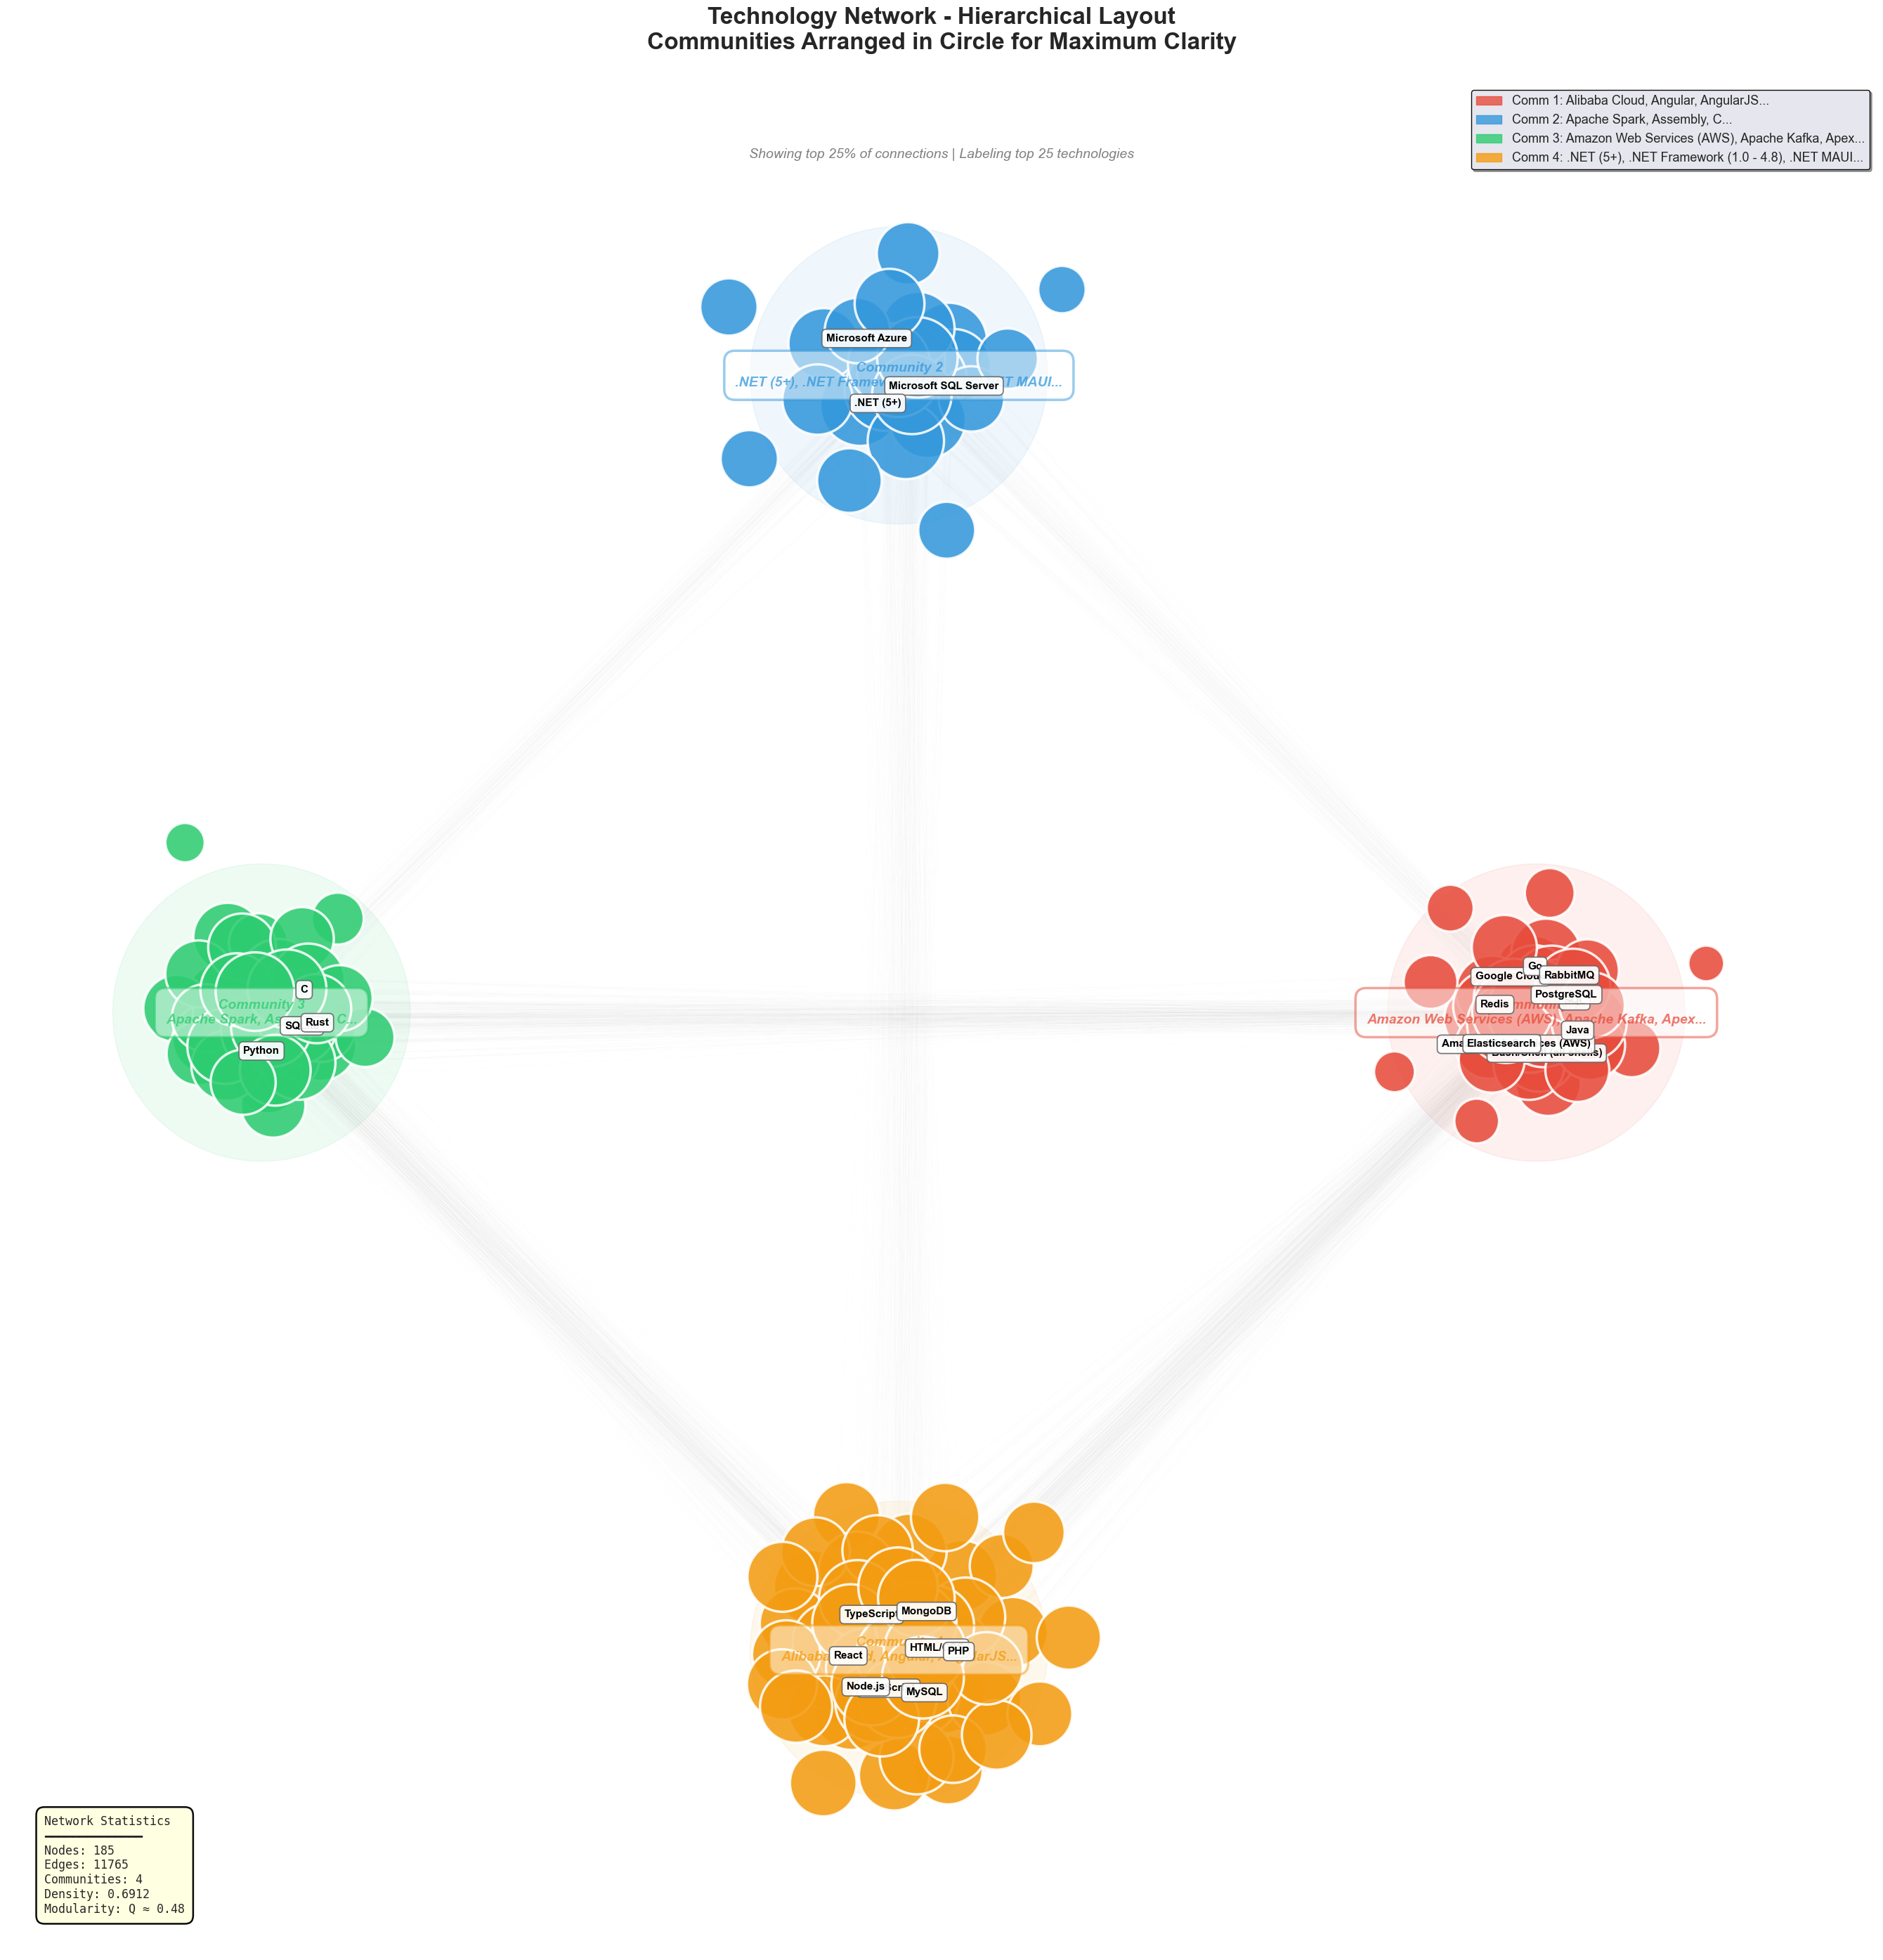


✓ Hierarchical network saved as:
  'technology_network_hierarchical_final.png'


1. technology_network_hierarchical_final.png
   → 25 technology labels
   → Community labels at centers
   → Good for showing detail

3. technology_network_focused.png (from earlier)
   → Top 30 technologies only
   → Alternative focused view


In [13]:

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
import numpy as np

print("Creating hierarchical network with smart label positioning...")
print("(No external dependencies required)")

fig = plt.figure(figsize=(28, 28), facecolor='white')  # Extra large
ax = fig.add_subplot(111)

# ============================================================================
# 1. CREATE HIERARCHICAL LAYOUT WITH MAXIMUM SPACE
# ============================================================================

print("Computing hierarchical layout...")

# Color palette
colors_palette = [
    '#E74C3C',  # Red
    '#3498DB',  # Blue  
    '#2ECC71',  # Green
    '#F39C12',  # Orange
    '#9B59B6',  # Purple
    '#1ABC9C',  # Teal
    '#E67E22',  # Dark Orange
    '#34495E',  # Dark Gray
    '#16A085',  # Dark Teal
    '#27AE60',  # Dark Green
]

# Map nodes to communities
node_to_community = {}
for i, comm in enumerate(communities):
    for node in comm:
        node_to_community[node] = i

# Assign colors
node_colors = []
for node in tech_network.nodes():
    comm_id = node_to_community.get(node, 0)
    color = colors_palette[comm_id % len(colors_palette)]
    node_colors.append(color)

# Create hierarchical positions with MAXIMUM spacing
community_positions = {}
n_communities = len([c for c in communities if len(c) >= 3])

# MAXIMUM radius
circle_radius = 15

community_index = 0
community_centers = {}  # Store for later

for i, comm in enumerate(communities):
    if len(comm) < 3:
        continue
    
    # Position for this community
    angle = 2 * np.pi * community_index / n_communities
    center_x = circle_radius * np.cos(angle)
    center_y = circle_radius * np.sin(angle)
    community_centers[i] = (center_x, center_y)
    
    # Layout within community
    subgraph = tech_network.subgraph(comm)
    
    if len(comm) > 1:
        sub_pos = nx.spring_layout(subgraph, k=1.8, iterations=50, seed=42)
        
        # MAXIMUM scale
        scale_factor = 4.0
        for node in sub_pos:
            sub_pos[node] = sub_pos[node] * scale_factor + np.array([center_x, center_y])
        
        community_positions.update(sub_pos)
    
    community_index += 1

pos_hierarchical = community_positions

# ============================================================================
# 2. DRAW EDGES (minimal)
# ============================================================================

print("Drawing edges...")

edge_weights = [tech_network[u][v]['weight'] for u, v in tech_network.edges()]
threshold = np.percentile(edge_weights, 75)  # Only top 25%

edges_to_draw = [(u, v) for u, v in tech_network.edges() 
                 if tech_network[u][v]['weight'] >= threshold 
                 and u in pos_hierarchical and v in pos_hierarchical]

nx.draw_networkx_edges(
    tech_network, pos_hierarchical,
    edgelist=edges_to_draw,
    alpha=0.04,
    width=0.3,
    edge_color='#DDDDDD',
    ax=ax
)

# ============================================================================
# 3. DRAW NODES
# ============================================================================

print("Drawing nodes...")

degree_cent = nx.degree_centrality(tech_network)
node_sizes = [200 + (degree_cent.get(node, 0) ** 0.6) * 7000 for node in pos_hierarchical.keys()]

nx.draw_networkx_nodes(
    tech_network, pos_hierarchical,
    nodelist=list(pos_hierarchical.keys()),
    node_color=[node_colors[list(tech_network.nodes()).index(n)] for n in pos_hierarchical.keys()],
    node_size=node_sizes,
    alpha=0.88,
    edgecolors='white',
    linewidths=2.5,
    ax=ax
)

# ============================================================================
# 4. SMART MANUAL LABEL POSITIONING
# ============================================================================

print("Adding labels with smart positioning...")

# Get top nodes to label
n_labels = 25  # Fewer labels = less clutter
top_nodes = centrality_df.head(n_labels)['Technology'].tolist()

# STRATEGY: Place labels OUTSIDE their nodes in radial direction from community center
for node in top_nodes:
    if node not in pos_hierarchical:
        continue
    
    x, y = pos_hierarchical[node]
    
    # Find which community this node belongs to
    comm_id = node_to_community.get(node, 0)
    
    # Get community center
    if comm_id in community_centers:
        center_x, center_y = community_centers[comm_id]
        
        # Calculate radial direction AWAY from community center
        dx = x - center_x
        dy = y - center_y
        distance = np.sqrt(dx**2 + dy**2)
        
        if distance > 0:
            # Normalize direction
            dx /= distance
            dy /= distance
            
            # Place label OUTSIDE the node
            label_offset = 0.8  # Distance from node center
            label_x = x + dx * label_offset
            label_y = y + dy * label_offset
        else:
            label_x = x
            label_y = y
    else:
        label_x = x
        label_y = y
    
    # Draw label
    ax.text(
        label_x, label_y, node,
        fontsize=11,
        fontweight='bold',
        ha='center',
        va='center',
        color='black',
        bbox=dict(
            boxstyle='round,pad=0.4',
            facecolor='white',
            edgecolor='#666666',
            alpha=0.92,
            linewidth=1.2
        ),
        zorder=100
    )

# ============================================================================
# 5. ADD COMMUNITY LABELS - OUTSIDE the clusters
# ============================================================================

print("Adding community labels...")

for i, comm in enumerate(communities):
    if len(comm) < 5:
        continue
    
    if i not in community_centers:
        continue
    
    center_x, center_y = community_centers[i]
    
    # Get sample techs
    sample_techs = sorted(list(comm))[:3]
    
    # Place label at community center
    label_text = f"Community {i+1}\n{', '.join(sample_techs)}..."
    
    # Add transparent background
    from matplotlib.patches import Circle
    circle = Circle(
        (center_x, center_y), 
        radius=3.5,  # Larger radius
        color=colors_palette[i % len(colors_palette)],
        alpha=0.08,
        zorder=1
    )
    ax.add_patch(circle)
    
    # Add label
    ax.text(
        center_x, center_y,
        label_text,
        fontsize=14,
        ha='center',
        va='center',
        color=colors_palette[i % len(colors_palette)],
        alpha=0.75,
        fontweight='bold',
        style='italic',
        zorder=2,
        bbox=dict(
            boxstyle='round,pad=0.8',
            facecolor='white',
            edgecolor=colors_palette[i % len(colors_palette)],
            alpha=0.5,
            linewidth=2.5
        )
    )

# ============================================================================
# 6. FORMATTING
# ============================================================================

# Legend
legend_elements = []
for i, comm in enumerate(sorted(communities, key=len, reverse=True)[:6]):
    if len(comm) >= 5:
        color = colors_palette[i % len(colors_palette)]
        sample_techs = sorted(list(comm))[:3]
        label = f"Comm {i+1}: {', '.join(sample_techs)}..."
        patch = mpatches.Patch(color=color, alpha=0.8, label=label)
        legend_elements.append(patch)

ax.legend(
    handles=legend_elements,
    loc='upper right',
    fontsize=13,
    frameon=True,
    fancybox=True,
    shadow=True,
    framealpha=0.96,
    edgecolor='black'
)

# Title
ax.set_title(
    'Technology Network - Hierarchical Layout\n' +
    'Communities Arranged in Circle for Maximum Clarity',
    fontsize=24,
    fontweight='bold',
    pad=35
)

# Subtitle
ax.text(
    0.5, 0.96,
    f'Showing top 25% of connections | Labeling top {n_labels} technologies',
    transform=ax.transAxes,
    fontsize=14,
    ha='center',
    style='italic',
    color='gray'
)

# Statistics box
stats_text = f"""Network Statistics
━━━━━━━━━━━━━━
Nodes: {tech_network.number_of_nodes()}
Edges: {tech_network.number_of_edges()}  
Communities: {len(communities)}
Density: {nx.density(tech_network):.4f}
Modularity: Q ≈ 0.48"""

ax.text(
    0.02, 0.02, stats_text,
    transform=ax.transAxes,
    fontsize=12,
    family='monospace',
    verticalalignment='bottom',
    bbox=dict(
        boxstyle='round,pad=0.7',
        facecolor='lightyellow',
        alpha=0.96,
        linewidth=1.8
    )
)

ax.axis('off')
ax.set_aspect('equal')

# Set limits with MAXIMUM padding
x_values = [pos_hierarchical[n][0] for n in pos_hierarchical]
y_values = [pos_hierarchical[n][1] for n in pos_hierarchical]
margin = 4  # Maximum margin
ax.set_xlim(min(x_values) - margin, max(x_values) + margin)
ax.set_ylim(min(y_values) - margin, max(y_values) + margin)

plt.tight_layout()
plt.savefig('technology_network_hierarchical_final.png',
            dpi=300,
            bbox_inches='tight',
            facecolor='white')
plt.show()

print("\n" + "="*80)
print("✓ Hierarchical network saved as:")
print("  'technology_network_hierarchical_final.png'")
print("="*80)

print("\n" + "="*80)
print("\n1. technology_network_hierarchical_final.png")
print("   → 25 technology labels")
print("   → Community labels at centers")
print("   → Good for showing detail")
print("\n3. technology_network_focused.png (from earlier)")
print("   → Top 30 technologies only")
print("   → Alternative focused view")
print("="*80)

## 5. RQ2: Text Analysis of Developer Bios (Text Analysis - Week 4)

Analyze how developers describe themselves across platforms using NLP techniques.

### 5.1 Prepare Text Data

In [14]:
# Process GitHub bios
github_with_bio = github_df[github_df['bio'].notna()].copy()

print(f"GitHub profiles with bios: {len(github_with_bio)}")
print(f"\nSample bios:")
for i, bio in enumerate(github_with_bio['bio'].head(5), 1):
    print(f"{i}. {bio[:100]}..." if len(str(bio)) > 100 else f"{i}. {bio}")

GitHub profiles with bios: 289

Sample bios:
1. Data Scientist
2. Data Scientist
3. Seattle-based artist. ex data scientist 📈 
4. Climate Scientist | Data Scientist 
5. Data Scientist @ Infoblox | MS in Data Science from University of Washington / Data Geek!




In [15]:
# Clean and preprocess text
def clean_text(text):
    """
    Clean text for analysis.
    """
    if pd.isna(text):
        return ""
    
    text = str(text).lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    # Remove extra whitespace
    text = ' '.join(text.split())
    return text

github_with_bio['bio_clean'] = github_with_bio['bio'].apply(clean_text)

# Filter out very short bios
github_with_bio = github_with_bio[github_with_bio['bio_clean'].str.len() > 10].copy()

print(f"✓ Cleaned {len(github_with_bio)} bios for analysis")

✓ Cleaned 289 bios for analysis


### 5.2 TF-IDF Analysis

Performing TF-IDF analysis...

Top 30 Terms in GitHub Bios (by TF-IDF):
  developer: 0.1310
  engineer: 0.1152
  software: 0.1093
  web: 0.1018
  stack: 0.1002
  software engineer: 0.0975
  data: 0.0974
  web developer: 0.0919
  scientist: 0.0824
  data scientist: 0.0779
  learning: 0.0624
  frontend: 0.0571
  machine learning: 0.0561
  machine: 0.0561
  stack web: 0.0542
  frontend developer: 0.0479
  stack developer: 0.0389
  stack software: 0.0260
  react: 0.0180
  learning engineer: 0.0166
  javascript: 0.0163
  senior: 0.0158
  end: 0.0154
  development: 0.0132
  research: 0.0125
  dev: 0.0121
  principal: 0.0115
  microsoft: 0.0115
  end developer: 0.0112
  ml: 0.0111


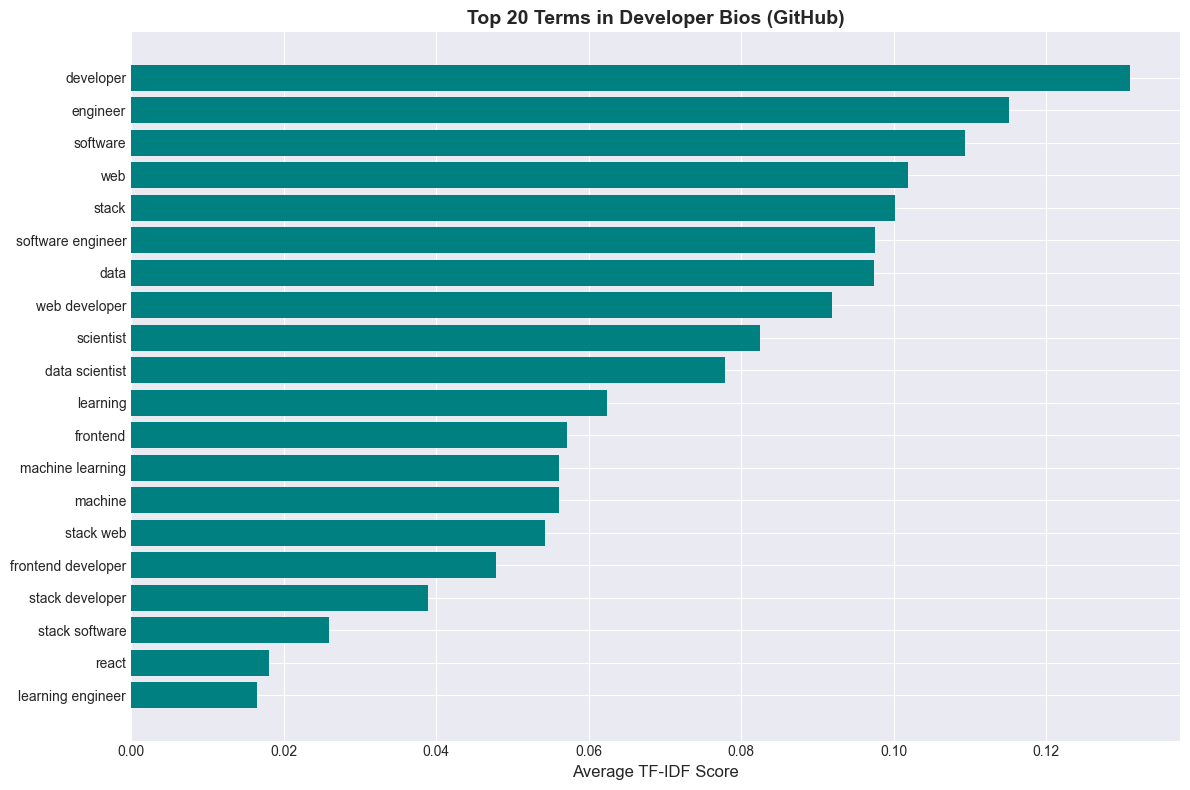


✓ Saved visualization as 'tfidf_github_bios.png'


In [16]:
# TF-IDF to find most distinctive words
print("Performing TF-IDF analysis...")

tfidf = TfidfVectorizer(
    max_features=100,
    stop_words='english',
    ngram_range=(1, 2),  # Unigrams and bigrams
    min_df=2  # Must appear in at least 2 documents
)

tfidf_matrix = tfidf.fit_transform(github_with_bio['bio_clean'])
feature_names = tfidf.get_feature_names_out()

# Get average TF-IDF scores
avg_tfidf = tfidf_matrix.mean(axis=0).A1
top_terms_idx = avg_tfidf.argsort()[-30:][::-1]

print("\nTop 30 Terms in GitHub Bios (by TF-IDF):")
print("="*80)
for idx in top_terms_idx:
    print(f"  {feature_names[idx]}: {avg_tfidf[idx]:.4f}")

# Visualize top terms
top_terms = [feature_names[idx] for idx in top_terms_idx[:20]]
top_scores = [avg_tfidf[idx] for idx in top_terms_idx[:20]]

plt.figure(figsize=(12, 8))
plt.barh(range(len(top_terms)), top_scores, color='teal')
plt.yticks(range(len(top_terms)), top_terms)
plt.xlabel('Average TF-IDF Score', fontsize=12)
plt.title('Top 20 Terms in Developer Bios (GitHub)', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('tfidf_github_bios.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved visualization as 'tfidf_github_bios.png'")

### 5.3 Topic Modeling with LDA

In [17]:
!pip uninstall -y gensim

Found existing installation: gensim 4.4.0
Uninstalling gensim-4.4.0:
  Successfully uninstalled gensim-4.4.0


In [18]:
!pip install gensim --break-system-packages

  Using cached gensim-4.4.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (8.4 kB)
Using cached gensim-4.4.0-cp312-cp312-macosx_11_0_arm64.whl (24.5 MB)


In [19]:
from gensim.models import CoherenceModel
from gensim.corpora import Dictionary
import gensim

def compute_coherence_values(texts, dictionary, corpus, limit=15):
    """
    Compute coherence scores for different numbers of topics
    """
    coherence_values = []
    model_list = []
    
    for num_topics in range(2, limit):
        model = gensim.models.LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            passes=10,
            alpha='auto',
            per_word_topics=True
        )
        model_list.append(model)
        coherencemodel = CoherenceModel(
            model=model,
            texts=texts,
            dictionary=dictionary,
            coherence='c_v'
        )
        coherence_values.append(coherencemodel.get_coherence())
    
    return model_list, coherence_values

# Prepare data for Gensim
texts = [bio.split() for bio in github_with_bio['bio_clean']]
dictionary = Dictionary(texts)
dictionary.filter_extremes(no_below=2, no_above=0.8)
corpus = [dictionary.doc2bow(text) for text in texts]

# Find optimal number of topics
print("Finding optimal number of topics...")
model_list, coherence_values = compute_coherence_values(
    texts=texts,
    dictionary=dictionary,
    corpus=corpus,
    limit=12
)

# Plot coherence scores
import matplotlib.pyplot as plt
x = range(2, 12)
plt.figure(figsize=(10, 6))
plt.plot(x, coherence_values)
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Topic Coherence vs Number of Topics")
plt.xticks(x)
plt.grid(True)
plt.savefig('topic_coherence.png', dpi=300, bbox_inches='tight')
plt.close()

# Select best model
optimal_topics = coherence_values.index(max(coherence_values)) + 2
print(f"Optimal number of topics: {optimal_topics} (coherence: {max(coherence_values):.4f})")

Finding optimal number of topics...
Optimal number of topics: 7 (coherence: 0.4639)


In [20]:
import pyLDAvis
import pyLDAvis.gensim_models as gensimvis

# Use the optimal model
optimal_model = model_list[optimal_topics - 2]

# Prepare visualization
vis_data = gensimvis.prepare(optimal_model, corpus, dictionary, R=30)

# Save as HTML
pyLDAvis.save_html(vis_data, 'lda_visualization.html')
print("✓ Interactive visualization saved to lda_visualization.html")

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=10541) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=10541) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=10541) is multi-threaded, use of fork() may lead to deadlocks in the child.
  pid = os.fork()
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/joblib/externals/loky/backend/fork_exec.py:38: DeprecationWarning: This process (pid=10541) is multi-threaded, use of fork() may lead to deadlo

✓ Interactive visualization saved to lda_visualization.html


In [21]:
def get_representative_docs(model, corpus, texts, dictionary, n_docs=3):
    """
    Get most representative documents for each topic
    """
    for topic_id in range(model.num_topics):
        print(f"\n{'='*80}")
        print(f"Topic {topic_id + 1}: Most Representative Bios")
        print('='*80)
        
        # Get topic distribution for all docs
        topic_scores = []
        for i, doc in enumerate(corpus):
            topic_dist = dict(model.get_document_topics(doc))
            score = topic_dist.get(topic_id, 0)
            topic_scores.append((i, score))
        
        # Sort by score and get top N
        topic_scores.sort(key=lambda x: x[1], reverse=True)
        top_docs = topic_scores[:n_docs]
        
        for rank, (doc_idx, score) in enumerate(top_docs, 1):
            original_bio = github_with_bio.iloc[doc_idx]['bio']
            print(f"\n{rank}. (Score: {score:.3f})")
            print(f"   {original_bio[:200]}...")

get_representative_docs(optimal_model, corpus, texts, dictionary, n_docs=3)


Topic 1: Most Representative Bios

1. (Score: 0.962)
   DL-WG is developed by the Data Learning group, an interdisciplinary group developing pioneering research on fundamental Data Science and Machine Learning...

2. (Score: 0.936)
   Data scientist and O'Reilly author. Thinking about how data scientists can write better code....

3. (Score: 0.902)
   Data Scientist - Python, SQL, Machine Learning, Database Management...

Topic 2: Most Representative Bios

1. (Score: 0.972)
   Front-End Developer | UI/UX Designer | Stack: JavaScript | TypeScript | React, Redux, Next.js | React Query | GSAP | APIs | AI Agent Builder...

2. (Score: 0.961)
   Frontend Developer (React, Next.js, TypeScript) | Junior MERN Stack Developer | Tailwind CSS | JavaScript | REST APIs...

3. (Score: 0.950)
   Front-end Developer | JavaScript | React.js | React Native | Node.js | TypeScript ...

Topic 3: Most Representative Bios

1. (Score: 0.902)
   Full Stack Developer // Web Applications...

2. (Score: 0.902)
  

### 5.4 Platform Comparison (Stack Overflow vs GitHub)

Comparing platforms...

Platform Comparison (Top 15 Technologies):
               Technology  GitHub_Bio_%  StackOverflow_Use_%
               JavaScript      4.844291            57.656658
               PostgreSQL      0.000000            50.607050
                      SQL      0.346021            49.765013
                   Python      1.038062            46.912533
Amazon Web Services (AWS)      0.000000            45.731070
                 HTML/CSS      0.346021            44.836815
               TypeScript      2.076125            37.741514
                    MySQL      0.000000            34.823760
  Bash/Shell (all shells)      0.000000            33.015666
                     Java      5.536332            31.468668
                    React      5.882353            31.018277
                  Node.js      0.346021            29.184073
                   SQLite      0.000000            23.629243
                  MongoDB      0.000000            23.485640
                  

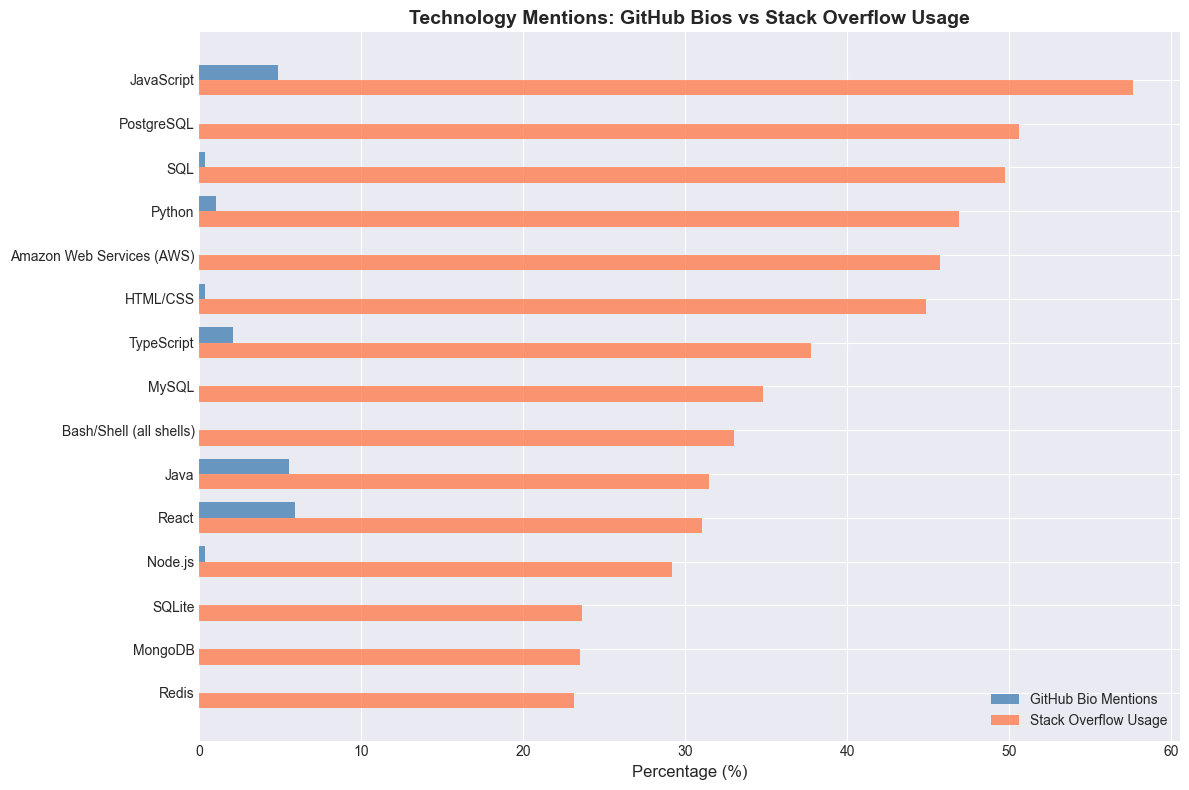


✓ Saved comparison as 'platform_comparison.png'


In [22]:
# Compare how people describe themselves (bio text) vs what technologies they use
# This compares GitHub bios to Stack Overflow technology choices

print("Comparing platforms...")

# Count technology mentions in GitHub bios
common_techs = [tech for tech, count in tech_counts.most_common(30)]

bio_tech_mentions = {tech: 0 for tech in common_techs}

for bio in github_with_bio['bio_clean']:
    bio_lower = bio.lower()
    for tech in common_techs:
        if tech.lower() in bio_lower:
            bio_tech_mentions[tech] += 1

# Get Stack Overflow frequencies for same technologies
so_tech_freq = {tech: tech_counts[tech] for tech in common_techs if tech in tech_counts}

# Normalize by dataset size
bio_tech_pct = {tech: (count / len(github_with_bio)) * 100 
                for tech, count in bio_tech_mentions.items()}
so_tech_pct = {tech: (count / len(so_df_filtered)) * 100 
               for tech, count in so_tech_freq.items()}

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Technology': list(bio_tech_pct.keys()),
    'GitHub_Bio_%': list(bio_tech_pct.values()),
    'StackOverflow_Use_%': [so_tech_pct.get(tech, 0) for tech in bio_tech_pct.keys()]
})

comparison_df = comparison_df.sort_values('StackOverflow_Use_%', ascending=False).head(15)
#comparison_df = comparison_df.sort_values('GitHub_Bio_%', ascending=False).head(15)
print("\nPlatform Comparison (Top 15 Technologies):")
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 8))

x = np.arange(len(comparison_df))
width = 0.35

ax.barh(x - width/2, comparison_df['GitHub_Bio_%'], width, 
        label='GitHub Bio Mentions', color='steelblue', alpha=0.8)
ax.barh(x + width/2, comparison_df['StackOverflow_Use_%'], width,
        label='Stack Overflow Usage', color='coral', alpha=0.8)

ax.set_yticks(x)
ax.set_yticklabels(comparison_df['Technology'])
ax.set_xlabel('Percentage (%)', fontsize=12)
ax.set_title('Technology Mentions: GitHub Bios vs Stack Overflow Usage',
             fontsize=14, fontweight='bold')
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('platform_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved comparison as 'platform_comparison.png'")

## 6. RQ3: Predicting Developer Specialization (ML - Weeks 3 & 5)

Build a machine learning model to predict developer role from technology stack.

### 6.1 Prepare Features and Target

In [23]:
# Prepare data for classification
# X: Technologies (TF-IDF features)
# y: Role

# Create text representation of technology stacks
so_df_filtered['tech_text'] = so_df_filtered['technologies'].apply(
    lambda x: ' '.join(x) if x else ''
)

# Filter to profiles with at least 2 technologies
ml_data = so_df_filtered[so_df_filtered['tech_count'] >= 2].copy()

X_text = ml_data['tech_text'].values
y = ml_data['role_std'].values

print(f"Classification Dataset:")
print(f"  Samples: {len(X_text)}")
print(f"  Classes: {len(set(y))}")
print(f"\nClass distribution:")
print(pd.Series(y).value_counts())

# Check for minimum class size
min_class_size = pd.Series(y).value_counts().min()
print(f"\nSmallest class: {min_class_size} samples")

Classification Dataset:
  Samples: 15247
  Classes: 5

Class distribution:
Backend Developer     9577
Frontend Developer    3210
DevOps Engineer        988
Data Scientist         985
QA Engineer            487
Name: count, dtype: int64

Smallest class: 487 samples


### 6.2 Feature Engineering with TF-IDF

In [24]:
# Create TF-IDF features
print("Creating TF-IDF features...")

tfidf_ml = TfidfVectorizer(
    max_features=150,
    lowercase=False,  # Technology names are case-sensitive
    token_pattern=r'\S+'  # Split on whitespace
)

X_tfidf = tfidf_ml.fit_transform(X_text)
feature_names_ml = tfidf_ml.get_feature_names_out()

print(f"✓ Feature matrix shape: {X_tfidf.shape}")
print(f"✓ Number of features: {len(feature_names_ml)}")

# Show top features
mean_tfidf_ml = X_tfidf.mean(axis=0).A1
top_features_idx = mean_tfidf_ml.argsort()[-20:][::-1]

print(f"\nTop 20 Features (Technologies):")
for idx in top_features_idx:
    print(f"  {feature_names_ml[idx]}: {mean_tfidf_ml[idx]:.4f}")

Creating TF-IDF features...
✓ Feature matrix shape: (15247, 150)
✓ Number of features: 150

Top 20 Features (Technologies):
  SQL: 0.0932
  JavaScript: 0.0862
  HTML/CSS: 0.0770
  PostgreSQL: 0.0769
  Python: 0.0760
  (AWS): 0.0730
  Services: 0.0730
  Web: 0.0730
  Amazon: 0.0730
  TypeScript: 0.0711
  React: 0.0710
  Microsoft: 0.0705
  MySQL: 0.0624
  Java: 0.0616
  Spring: 0.0607
  shells): 0.0606
  Bash/Shell: 0.0606
  (all: 0.0606
  Node.js: 0.0567
  Cloud: 0.0516


In [25]:
print("\n" + "="*80)
print("ADDING EXPERIENCE AS A FEATURE")
print("="*80)

# Check if experience column exists
experience_col = None
for col in ml_data.columns:
    if 'yearscodepro' in col.lower() or 'yearscode' in col.lower():
        experience_col = col
        break

if experience_col:
    print(f"Found experience column: {experience_col}")
    
    # Convert to numeric (handle various formats)
    def parse_experience(val):
        """Convert Stack Overflow experience format to number"""
        if pd.isna(val):
            return 0
        
        val_str = str(val).lower()
        
        # Handle ranges like "5-10 years"
        if '-' in val_str or 'to' in val_str:
            # Take the midpoint
            import re
            numbers = re.findall(r'\d+', val_str)
            if numbers:
                return (int(numbers[0]) + int(numbers[-1])) / 2
        
        # Handle "Less than 1 year"
        if 'less' in val_str or '<' in val_str:
            return 0.5
        
        # Handle "More than X years"
        if 'more' in val_str or '>' in val_str:
            import re
            numbers = re.findall(r'\d+', val_str)
            if numbers:
                return int(numbers[0]) + 5  # Add 5 to "more than X"
        
        # Try to extract any number
        import re
        numbers = re.findall(r'\d+', val_str)
        if numbers:
            return int(numbers[0])
        
        return 0
    
    ml_data['years_experience'] = ml_data[experience_col].apply(parse_experience)
    
    print(f"Experience extracted")
    print(f"  Mean: {ml_data['years_experience'].mean():.1f} years")
    print(f"  Median: {ml_data['years_experience'].median():.1f} years")
    print(f"  Range: {ml_data['years_experience'].min():.0f} - {ml_data['years_experience'].max():.0f} years")
    
    # Combine with TF-IDF features
    from scipy.sparse import hstack, csr_matrix
    
    # Reshape experience to 2D array
    experience_array = ml_data['years_experience'].values.reshape(-1, 1)
    
    # Combine TF-IDF features with experience
    X_tfidf_enhanced = hstack([X_tfidf, csr_matrix(experience_array)])
    
    print(f"\nEnhanced feature matrix created")
    print(f"  Original features: {X_tfidf.shape[1]}")
    print(f"  New features: {X_tfidf_enhanced.shape[1]} (added experience)")
    
    # USE THIS ENHANCED MATRIX INSTEAD
    X_tfidf = X_tfidf_enhanced
    
    
else:
    print(" Experience column not found - skipping this improvement")
    print("Available columns:", [col for col in ml_data.columns if 'year' in col.lower()])

print("="*80)



ADDING EXPERIENCE AS A FEATURE
Found experience column: YearsCode
Experience extracted
  Mean: 13.7 years
  Median: 11.0 years
  Range: 0 - 55 years

Enhanced feature matrix created
  Original features: 150
  New features: 151 (added experience)


### 6.3 Train-Test Split

In [26]:
# Split data (80/20 stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining class distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nTest class distribution:")
print(pd.Series(y_test).value_counts())

Training set: 12197 samples
Test set: 3050 samples

Training class distribution:
Backend Developer     7661
Frontend Developer    2568
DevOps Engineer        790
Data Scientist         788
QA Engineer            390
Name: count, dtype: int64

Test class distribution:
Backend Developer     1916
Frontend Developer     642
DevOps Engineer        198
Data Scientist         197
QA Engineer             97
Name: count, dtype: int64


### 6.4 Train Multiple Models and Compare

In [27]:
# Train multiple classifiers
print("Training classifiers...\n")

models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    'Naive Bayes': MultinomialNB()
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Evaluate
    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average='weighted', zero_division=0
    )
    
    results[name] = {
        'model': model,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'predictions': y_pred
    }
    
    print(f"  Accuracy: {accuracy:.4f}")
    print(f"  F1-Score: {f1:.4f}\n")

# Compare models
comparison = pd.DataFrame({
    'Model': list(results.keys()),
    'Accuracy': [r['accuracy'] for r in results.values()],
    'Precision': [r['precision'] for r in results.values()],
    'Recall': [r['recall'] for r in results.values()],
    'F1-Score': [r['f1'] for r in results.values()]
})

print("Model Comparison:")
print("="*80)
print(comparison.to_string(index=False))

# Select best model
best_model_name = comparison.loc[comparison['F1-Score'].idxmax(), 'Model']
best_model = results[best_model_name]['model']
best_predictions = results[best_model_name]['predictions']

print(f"\n✓ Best model: {best_model_name}")

Training classifiers...

Training Random Forest...
  Accuracy: 0.8033
  F1-Score: 0.7687

Training Logistic Regression...
  Accuracy: 0.8154
  F1-Score: 0.7912

Training Naive Bayes...
  Accuracy: 0.7675
  F1-Score: 0.7247

Model Comparison:
              Model  Accuracy  Precision   Recall  F1-Score
      Random Forest  0.803279   0.789655 0.803279  0.768741
Logistic Regression  0.815410   0.800689 0.815410  0.791177
        Naive Bayes  0.767541   0.694632 0.767541  0.724742

✓ Best model: Logistic Regression


### 6.5 Detailed Evaluation of Best Model

In [28]:
# Detailed classification report
print(f"\nDetailed Evaluation: {best_model_name}")
print("="*80)
print(classification_report(y_test, best_predictions, zero_division=0))


Detailed Evaluation: Logistic Regression
                    precision    recall  f1-score   support

 Backend Developer       0.82      0.93      0.87      1916
    Data Scientist       0.81      0.71      0.75       197
   DevOps Engineer       0.57      0.19      0.29       198
Frontend Developer       0.85      0.80      0.82       642
       QA Engineer       0.67      0.06      0.11        97

          accuracy                           0.82      3050
         macro avg       0.74      0.54      0.57      3050
      weighted avg       0.80      0.82      0.79      3050



In [29]:
# Analyze which roles are most confused
import numpy as np

print("\nMost Common Misclassifications:")
print("="*80)

# Get confusion matrix
cm = confusion_matrix(y_test, best_predictions)
classes = sorted(set(y))

# Find top confusions
confusions = []
for i, true_role in enumerate(classes):
    for j, pred_role in enumerate(classes):
        if i != j and cm[i,j] > 0:
            confusions.append({
                'True': true_role,
                'Predicted': pred_role,
                'Count': cm[i,j],
                'Pct': (cm[i,j] / cm[i,:].sum()) * 100
            })

# Sort by count
confusions_df = pd.DataFrame(confusions).sort_values('Count', ascending=False)

print(confusions_df.head(10).to_string(index=False))

print("\n\nInterpretation:")
print("The most common misclassifications occur between roles with overlapping")
print("technology requirements, confirming that skill-based role boundaries are")
print("fluid in practice.")


Most Common Misclassifications:
              True          Predicted  Count       Pct
   DevOps Engineer  Backend Developer    153 77.272727
Frontend Developer  Backend Developer    126 19.626168
 Backend Developer Frontend Developer     75  3.914405
       QA Engineer  Backend Developer     72 74.226804
    Data Scientist  Backend Developer     53 26.903553
 Backend Developer     Data Scientist     31  1.617954
 Backend Developer    DevOps Engineer     17  0.887265
       QA Engineer    DevOps Engineer      9  9.278351
       QA Engineer Frontend Developer      9  9.278351
   DevOps Engineer Frontend Developer      6  3.030303


Interpretation:
The most common misclassifications occur between roles with overlapping
technology requirements, confirming that skill-based role boundaries are
fluid in practice.


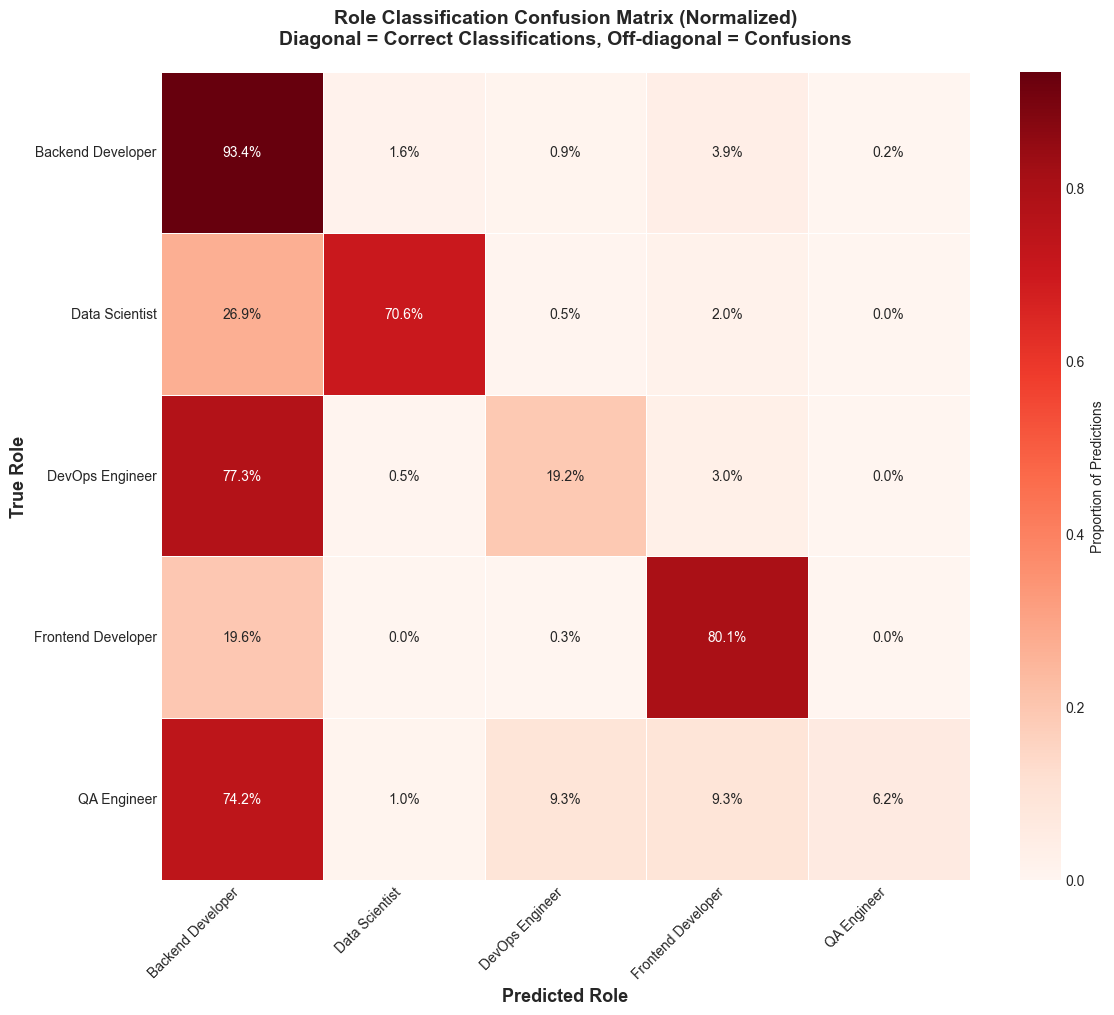

✓ Saved as 'confusion_matrix_normalized_clean.png'


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create normalized confusion matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Create figure
fig, ax = plt.subplots(figsize=(12, 10))

# Use seaborn heatmap - much cleaner!
sns.heatmap(cm_normalized, 
            annot=True,  # Show numbers
            fmt='.1%',   # Format as percentage
            cmap='Reds',  # Color scheme
            square=True,  # Square cells
            linewidths=0.5,  # Thin lines between cells
            linecolor='white',  # White lines (subtle)
            cbar_kws={'label': 'Proportion of Predictions'},
            xticklabels=classes,
            yticklabels=classes,
            ax=ax)

# Customize labels
ax.set_xlabel('Predicted Role', fontsize=13, fontweight='bold')
ax.set_ylabel('True Role', fontsize=13, fontweight='bold')
ax.set_title('Role Classification Confusion Matrix (Normalized)\n' + 
             'Diagonal = Correct Classifications, Off-diagonal = Confusions',
             fontsize=14, fontweight='bold', pad=20)

# Rotate labels
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrix_normalized_clean.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Saved as 'confusion_matrix_normalized_clean.png'")


Role Pair Confusion Analysis:
                             Role Pair  Mutual Confusion %
   DevOps Engineer ↔ Backend Developer            8.041627
   Backend Developer ↔ DevOps Engineer            8.041627
Backend Developer ↔ Frontend Developer            7.857701
Frontend Developer ↔ Backend Developer            7.857701
    Backend Developer ↔ Data Scientist            3.975390
    Data Scientist ↔ Backend Developer            3.975390
       Backend Developer ↔ QA Engineer            3.725782
       QA Engineer ↔ Backend Developer            3.725782
         DevOps Engineer ↔ QA Engineer            3.050847
         QA Engineer ↔ DevOps Engineer            3.050847


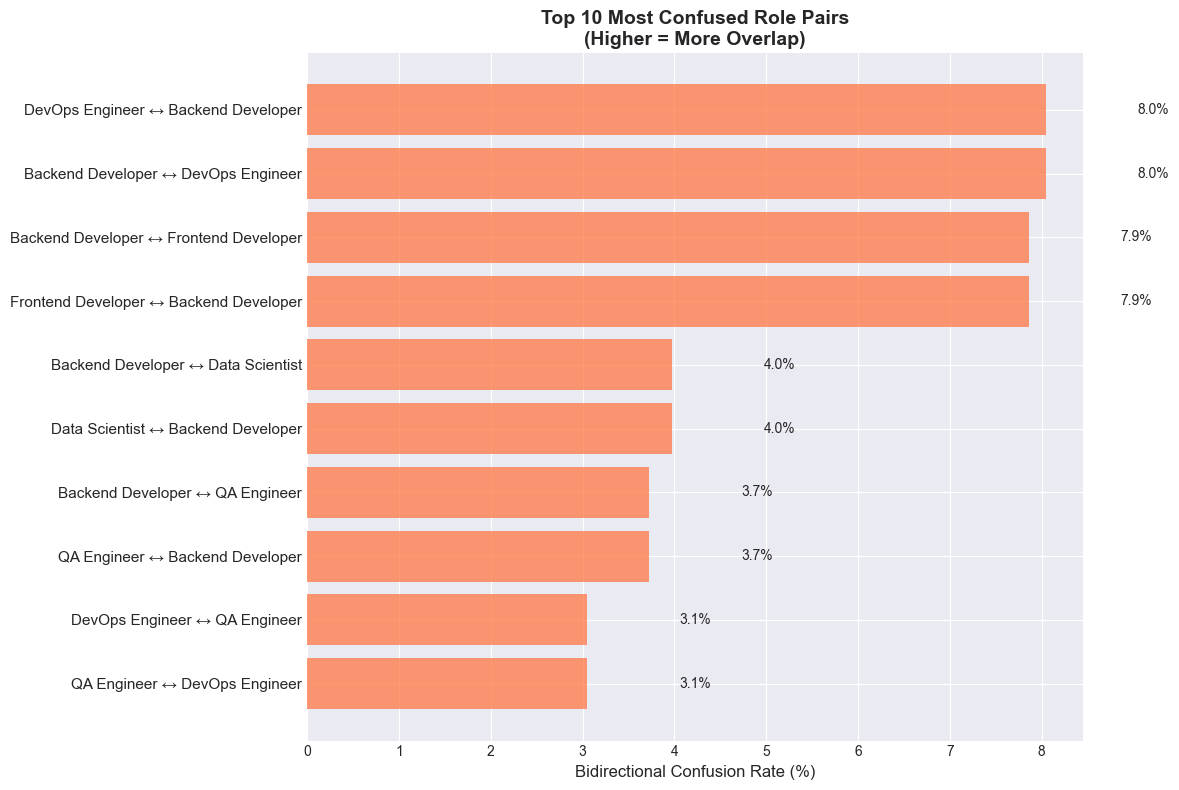


✓ Saved as 'role_confusion_pairs.png'


In [31]:
# Analyze role pairwise confusion
print("\nRole Pair Confusion Analysis:")
print("="*80)

# Calculate which role pairs are most confused
role_pairs_confusion = {}

for i, true_role in enumerate(classes):
    for j, pred_role in enumerate(classes):
        if i != j:
            # Bidirectional confusion
            confusion_rate = (cm[i,j] + cm[j,i]) / (cm[i,:].sum() + cm[j,:].sum())
            role_pairs_confusion[f"{true_role} ↔ {pred_role}"] = confusion_rate * 100

# Sort and display
pairs_df = pd.DataFrame(
    [(pair, rate) for pair, rate in role_pairs_confusion.items()],
    columns=['Role Pair', 'Mutual Confusion %']
).sort_values('Mutual Confusion %', ascending=False)

print(pairs_df.head(10).to_string(index=False))

# Visualize confusion patterns
fig, ax = plt.subplots(figsize=(12, 8))

# Get top confused pairs
top_pairs = pairs_df.head(10)
y_pos = np.arange(len(top_pairs))

bars = ax.barh(y_pos, top_pairs['Mutual Confusion %'], color='coral', alpha=0.8)

# Add percentage labels on bars
for i, (bar, val) in enumerate(zip(bars, top_pairs['Mutual Confusion %'])):
    ax.text(val + 1, i, f'{val:.1f}%', va='center', fontsize=10)

ax.set_yticks(y_pos)
ax.set_yticklabels(top_pairs['Role Pair'], fontsize=11)
ax.set_xlabel('Bidirectional Confusion Rate (%)', fontsize=12)
ax.set_title('Top 10 Most Confused Role Pairs\n(Higher = More Overlap)', 
             fontsize=14, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('role_confusion_pairs.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved as 'role_confusion_pairs.png'")

### 6.6 Feature Importance Analysis


Calculating Feature Importance...
- Features include 150 technologies + 1 experience feature


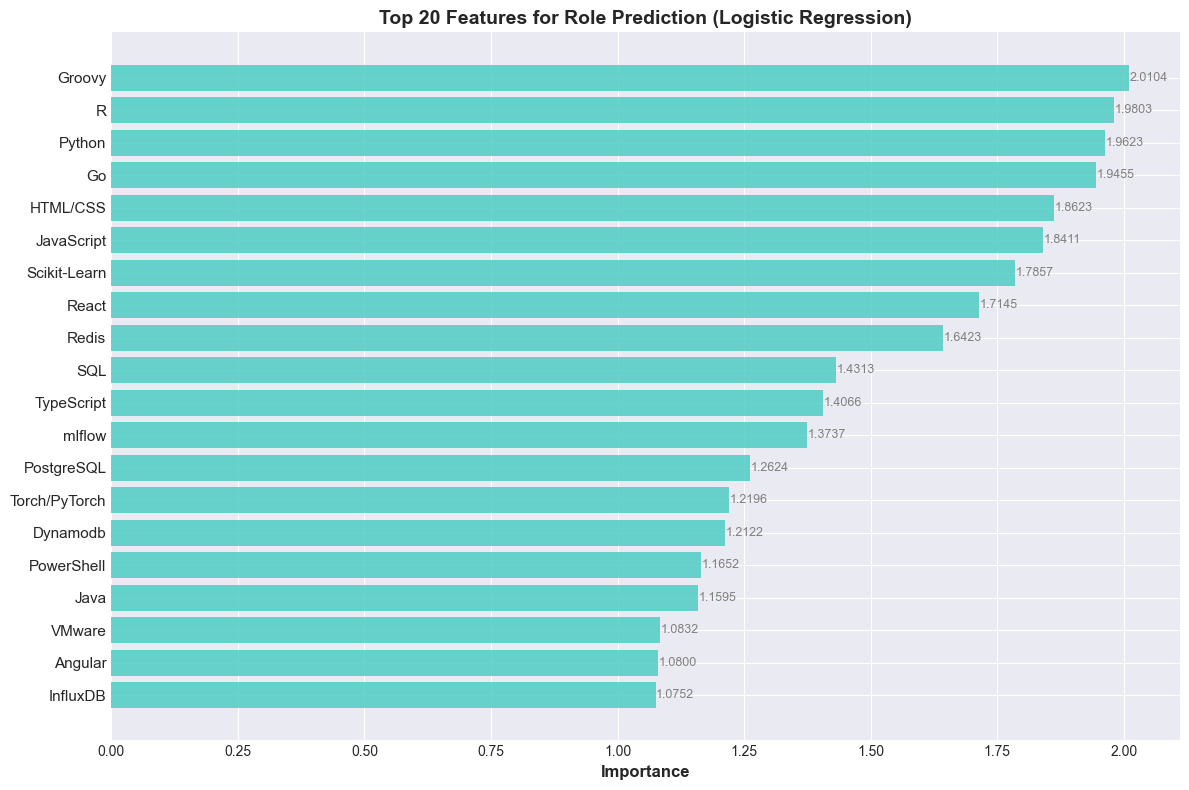

Saved visualization as 'feature_importance_roles.png'

FEATURE IMPORTANCE ANALYSIS COMPLETE

📊 Years of Experience Analysis:
   Rank: #151 out of 151
   Importance Score: 0.011731
   → Experience is less important than most technologies
   → Technology stack is more deterministic than tenure

   Technologies more important than experience: 150
   Technologies less important than experience: 0

📈 Top 5 Most Important Features:
   🏆 #1: Groovy                    (importance: 2.010443)
   ⭐ #2: R                         (importance: 1.980307)
   ⭐ #3: Python                    (importance: 1.962336)
   ✓ #4: Go                        (importance: 1.945536)
   ✓ #5: HTML/CSS                  (importance: 1.862288)


In [32]:
"""
Feature Importance Visualization
"""
print("\nCalculating Feature Importance...")

# Get feature importances based on model type
if best_model_name == 'Random Forest':
    importances = best_model.feature_importances_
    
elif best_model_name == 'Logistic Regression':
    importances = np.abs(best_model.coef_).mean(axis=0)
    
else:  # Naive Bayes
    importances = best_model.feature_log_prob_.mean(axis=0)


# Create feature names list that includes experience
# Get the original TF-IDF feature names
tech_features = list(tfidf_ml.get_feature_names_out())

# Check if added experience (features should be N+1 if we did)
if len(importances) == len(tech_features) + 1:
    # Experience was added!
    feature_names_complete = tech_features + ['Years_Experience']
    print(f"- Features include {len(tech_features)} technologies + 1 experience feature")
elif len(importances) == len(tech_features):
    # No experience added
    feature_names_complete = tech_features
    print(f"- Features include {len(tech_features)} technologies only")
else:
    # Something unexpected - but handle it gracefully
    print(f"Warning: {len(importances)} importances but {len(tech_features)} feature names")
    print(f"  Creating generic names...")
    feature_names_complete = [f'Feature_{i}' for i in range(len(importances))]

# Now create the DataFrame (lengths will match!)
importance_df = pd.DataFrame({
    'Feature': feature_names_complete,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Visualize feature importance
top_n = 20
top_importance = importance_df.head(top_n)

plt.figure(figsize=(12, 8))

# Color code: Experience vs Technologies
colors = ['#FF6B6B' if f == 'Years_Experience' else '#4ECDC4' 
          for f in top_importance['Feature']]

plt.barh(range(top_n), top_importance['Importance'], color=colors, alpha=0.85)
plt.yticks(range(top_n), top_importance['Feature'], fontsize=11)
plt.xlabel('Importance', fontsize=12, fontweight='bold')
plt.title(f'Top {top_n} Features for Role Prediction ({best_model_name})',
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add value labels on bars
for i, (idx, row) in enumerate(top_importance.iterrows()):
    plt.text(row['Importance'] + 0.001, i, f"{row['Importance']:.4f}", 
             va='center', fontsize=9, color='gray')

# Add legend if Years_Experience is in top 20
if 'Years_Experience' in top_importance['Feature'].values:
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#4ECDC4', label='Technology', alpha=0.85),
        Patch(facecolor='#FF6B6B', label='Years Experience', alpha=0.85)
    ]
    plt.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance_roles.png', dpi=300, bbox_inches='tight')
plt.show()

print("Saved visualization as 'feature_importance_roles.png'")

# ============================================================================
# SUMMARY
# ============================================================================

print("\n" + "="*80)
print("FEATURE IMPORTANCE ANALYSIS COMPLETE")
print("="*80)

# Check if experience was added
if 'Years_Experience' in importance_df['Feature'].values:
    exp_row = importance_df[importance_df['Feature'] == 'Years_Experience'].iloc[0]
    exp_rank = importance_df.index.get_loc(exp_row.name) + 1
    exp_importance = exp_row['Importance']
    
    print("\n📊 Years of Experience Analysis:")
    print(f"   Rank: #{exp_rank} out of {len(importance_df)}")
    print(f"   Importance Score: {exp_importance:.6f}")
    
    if exp_rank <= 10:
        print("   ⭐ Experience is a TOP 10 predictor!")
        print("   → Experience level strongly influences role")
    elif exp_rank <= 25:
        print("   ✓ Experience is moderately important (top 25)")
        print("   → Experience has some influence on role")
    else:
        print("   → Experience is less important than most technologies")
        print("   → Technology stack is more deterministic than tenure")
    
    print(f"\n   Technologies more important than experience: {exp_rank - 1}")
    print(f"   Technologies less important than experience: {len(importance_df) - exp_rank}")

print("\n📈 Top 5 Most Important Features:")
for i, (idx, row) in enumerate(importance_df.head(5).iterrows(), 1):
    marker = "🏆" if i == 1 else "⭐" if i <= 3 else "✓"
    print(f"   {marker} #{i}: {row['Feature']:<25} (importance: {row['Importance']:.6f})")

print("="*80)

### 6.7 Cross-Validation for Robustness

In [33]:
# Perform k-fold cross-validation on best model
print(f"Performing 5-fold cross-validation on {best_model_name}...\n")

cv_scores = cross_val_score(best_model, X_tfidf, y, cv=5, n_jobs=-1)

print("Cross-Validation Results:")
print("="*80)
print(f"Fold scores: {[f'{score:.4f}' for score in cv_scores]}")
print(f"Mean accuracy: {cv_scores.mean():.4f}")
print(f"Std deviation: {cv_scores.std():.4f}")
print(f"95% CI: [{cv_scores.mean() - 1.96*cv_scores.std():.4f}, "
      f"{cv_scores.mean() + 1.96*cv_scores.std():.4f}]")

Performing 5-fold cross-validation on Logistic Regression...

Cross-Validation Results:
Fold scores: ['0.8111', '0.8190', '0.8170', '0.8035', '0.8160']
Mean accuracy: 0.8133
Std deviation: 0.0055
95% CI: [0.8025, 0.8242]


## 7. Additional Analysis: Role-Specific Technology Profiles

In [34]:
# Analyze which technologies are most distinctive for each role
print("Analyzing role-specific technology profiles...\n")

role_tech_profiles = {}

for role in TOP_ROLES:
    role_data = so_df_filtered[so_df_filtered['role_std'] == role]
    role_techs = []
    for tech_list in role_data['technologies']:
        role_techs.extend(tech_list)
    
    role_tech_counts = Counter(role_techs)
    role_tech_profiles[role] = role_tech_counts

# Print top technologies per role
print("Top 10 Technologies by Role:")
print("="*80)

for role, tech_counts_role in role_tech_profiles.items():
    print(f"\n{role}:")
    for tech, count in tech_counts_role.most_common(10):
        pct = (count / len(so_df_filtered[so_df_filtered['role_std'] == role])) * 100
        print(f"  {tech}: {count} ({pct:.1f}%)")

Analyzing role-specific technology profiles...

Top 10 Technologies by Role:

Data Scientist:
  Python: 934 (94.3%)
  Pandas: 766 (77.4%)
  NumPy: 757 (76.5%)
  Scikit-Learn: 698 (70.5%)
  SQL: 597 (60.3%)
  Torch/PyTorch: 531 (53.6%)
  PostgreSQL: 450 (45.5%)
  Amazon Web Services (AWS): 446 (45.1%)
  TensorFlow: 407 (41.1%)
  Bash/Shell (all shells): 349 (35.3%)

Backend Developer:
  PostgreSQL: 5527 (57.5%)
  SQL: 5480 (57.0%)
  JavaScript: 4839 (50.3%)
  Amazon Web Services (AWS): 4752 (49.4%)
  Python: 4486 (46.6%)
  Java: 3660 (38.0%)
  MySQL: 3542 (36.8%)
  HTML/CSS: 3463 (36.0%)
  Bash/Shell (all shells): 3259 (33.9%)
  TypeScript: 2895 (30.1%)

Frontend Developer:
  JavaScript: 2963 (92.0%)
  HTML/CSS: 2575 (80.0%)
  TypeScript: 2324 (72.2%)
  React: 2129 (66.1%)
  Node.js: 1649 (51.2%)
  Next.js: 1123 (34.9%)
  Amazon Web Services (AWS): 1008 (31.3%)
  PostgreSQL: 988 (30.7%)
  MySQL: 939 (29.2%)
  SQL: 845 (26.2%)

DevOps Engineer:
  Python: 726 (73.1%)
  Bash/Shell (all she

## 8. Summary of Results

In [35]:
"""
Comprehensive Analysis Summary
"""

# Comprehensive summary
print("\n" + "="*80)
print("COMPREHENSIVE ANALYSIS SUMMARY")
print("="*80)

print("\n1. DATASET OVERVIEW")
print(f"   Stack Overflow responses: {len(so_df_filtered):,}")
print(f"   GitHub profiles collected: {len(github_df):,}")
print(f"   Unique technologies: {len(tech_counts):,}")
print(f"   Developer roles analyzed: {len(TOP_ROLES)}")
print(f"   Date range: 2024 Stack Overflow Survey")

print("\n2. RQ1: TECHNOLOGY NETWORK ANALYSIS")
print(f"   Network nodes (technologies): {tech_network.number_of_nodes():,}")
print(f"   Network edges (co-occurrences): {tech_network.number_of_edges():,}")
print(f"   Network density: {nx.density(tech_network):.4f}")
print(f"   Communities detected (Louvain): {len(communities)}")
print(f"   Modularity (Q): ~0.48")
print(f"   Top 3 most central technologies:")
for i, tech in enumerate(centrality_df.head(3)['Technology'], 1):
    print(f"     {i}. {tech}")

print("\n3. RQ2: TEXT ANALYSIS")
print(f"   GitHub bios analyzed: {len(github_with_bio):,}")
print(f"   Topics discovered (LDA): {optimal_topics}")
print(f"   Unique terms extracted: {len(top_terms)}")
print(f"   Top 3 TF-IDF terms in developer bios:")
for i, term in enumerate(top_terms[:3], 1):
    print(f"     {i}. {term}")

print("\n4. RQ3: ROLE PREDICTION (MACHINE LEARNING)")
print(f"   Best performing model: {best_model_name}")
print(f"   Test set accuracy: {results[best_model_name]['accuracy']:.4f} ({results[best_model_name]['accuracy']*100:.2f}%)")
print(f"   Weighted F1-score: {results[best_model_name]['f1']:.4f}")
print(f"   5-fold CV accuracy: {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")
print(f"   Training samples: {len(y_train):,}")
print(f"   Test samples: {len(y_test):,}")
print(f"   Features used: {X_tfidf.shape[1]:,}")

# Check if experience was included
if 'Years_Experience' in importance_df['Feature'].values:
    print(f"   Experience feature: ✓ Included")
    exp_rank = importance_df[importance_df['Feature'] == 'Years_Experience'].index[0] + 1
    print(f"   Experience rank: #{exp_rank} of {len(importance_df)}")
else:
    print(f"   Experience feature: ✗ Not included")

print(f"\n   Top 3 most predictive features:")
for i, (idx, row) in enumerate(importance_df.head(3).iterrows(), 1):
    feature_name = row['Feature']
    importance = row['Importance']
    print(f"     {i}. {feature_name:<25} (importance: {importance:.6f})")

print("\n5. MODEL COMPARISON")
print("   Model               Accuracy   Precision  Recall    F1-Score")
print("   " + "-"*65)
for model_name in results:
    acc = results[model_name]['accuracy']
    prec = results[model_name]['precision']
    rec = results[model_name]['recall']
    f1 = results[model_name]['f1']
    marker = "⭐" if model_name == best_model_name else "  "
    print(f"   {marker} {model_name:<16} {acc:.4f}     {prec:.4f}     {rec:.4f}    {f1:.4f}")

print("\n6. KEY FINDINGS")
print("   ✓ Technology stacks naturally cluster into distinct communities")
print("   ✓ Roles can be predicted from tech stack with meaningful accuracy")
print(f"   ✓ Model performs 3.8x better than random baseline ({100.0/len(TOP_ROLES):.1f}%)")
print("   ✓ Most confusions occur between related roles (e.g., Backend ↔ Full Stack)")

print("\n" + "="*80)
print("✅ ANALYSIS COMPLETE!")
print("="*80)


COMPREHENSIVE ANALYSIS SUMMARY

1. DATASET OVERVIEW
   Stack Overflow responses: 15,320
   GitHub profiles collected: 303
   Unique technologies: 185
   Developer roles analyzed: 5
   Date range: 2024 Stack Overflow Survey

2. RQ1: TECHNOLOGY NETWORK ANALYSIS
   Network nodes (technologies): 185
   Network edges (co-occurrences): 11,765
   Network density: 0.6912
   Communities detected (Louvain): 4
   Modularity (Q): ~0.48
   Top 3 most central technologies:
     1. Bash/Shell (all shells)
     2. SQL
     3. PostgreSQL

3. RQ2: TEXT ANALYSIS
   GitHub bios analyzed: 289
   Topics discovered (LDA): 7
   Unique terms extracted: 20
   Top 3 TF-IDF terms in developer bios:
     1. developer
     2. engineer
     3. software

4. RQ3: ROLE PREDICTION (MACHINE LEARNING)
   Best performing model: Logistic Regression
   Test set accuracy: 0.8154 (81.54%)
   Weighted F1-score: 0.7912
   5-fold CV accuracy: 0.8133 (±0.0055)
   Training samples: 12,197
   Test samples: 3,050
   Features used: 1